In [1]:
# Level 2 - Task 2: Time Series Analysis

## Apple Stock Price Analysis

#This project analyzes Apple (AAPL) stock price data over time to identify
#trends, potential seasonal patterns, and short-term fluctuations using
#time series analysis techniques.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv(r"D:\projects\codveda project\csv\2) Stock Prices Data Set.csv")

df.head()

,symbol,date,open,high,low,close,volume
0,AAL,1/2/2014,25.0700,25.8200,25.0600,25.3600,8998943
1,AAPL,1/2/2014,79.3828,79.5756,78.8601,79.0185,58791957
2,AAP,1/2/2014,110.3600,111.8800,109.2900,109.7400,542711
3,ABBV,1/2/2014,52.1200,52.3300,51.5200,51.9800,4569061
4,ABC,1/2/2014,70.1100,70.2300,69.4800,69.8900,1148391


In [4]:
df.shape

(497472, 7)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 497472 entries, 0 to 497471
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   symbol  497472 non-null  object 
 1   date    497472 non-null  object 
 2   open    497461 non-null  float64
 3   high    497464 non-null  float64
 4   low     497464 non-null  float64
 5   close   497472 non-null  float64
 6   volume  497472 non-null  int64  
dtypes: float64(4), int64(1), object(2)
memory usage: 26.6+ MB


In [6]:
df["date"] = pd.to_datetime(df["date"])

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 497472 entries, 0 to 497471
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   symbol  497472 non-null  object        
 1   date    497472 non-null  datetime64[ns]
 2   open    497461 non-null  float64       
 3   high    497464 non-null  float64       
 4   low     497464 non-null  float64       
 5   close   497472 non-null  float64       
 6   volume  497472 non-null  int64         
dtypes: datetime64[ns](1), float64(4), int64(1), object(1)
memory usage: 26.6+ MB


In [8]:
apple = df[df["symbol"] == "AAPL"].copy()

In [9]:
apple.head()

,symbol,date,open,high,low,close,volume
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957
484,AAPL,2014-01-03,78.9799,79.0999,77.2042,77.2828,98303870
967,AAPL,2014-01-06,76.7785,78.1142,76.2285,77.7042,103359151
1450,AAPL,2014-01-07,77.7599,77.9942,76.8464,77.1481,79432766
1933,AAPL,2014-01-08,76.9728,77.9371,76.9556,77.6371,64686685


In [10]:
apple = apple.sort_values("date")

In [11]:
apple[["date", "close"]].head()

,date,close
1,2014-01-02,79.0185
484,2014-01-03,77.2828
967,2014-01-06,77.7042
1450,2014-01-07,77.1481
1933,2014-01-08,77.6371


In [12]:
apple[["date", "close"]].tail()

,date,close
494948,2017-12-22,175.01
495453,2017-12-26,170.57
495958,2017-12-27,170.60
496463,2017-12-28,171.08
496968,2017-12-29,169.23


In [13]:
apple = apple.set_index("date")

In [14]:
apple.head()

,symbol,open,high,low,close,volume
date,,,,,,
2014-01-02,AAPL,79.3828,79.5756,78.8601,79.0185,58791957
2014-01-03,AAPL,78.9799,79.0999,77.2042,77.2828,98303870
2014-01-06,AAPL,76.7785,78.1142,76.2285,77.7042,103359151
2014-01-07,AAPL,77.7599,77.9942,76.8464,77.1481,79432766
2014-01-08,AAPL,76.9728,77.9371,76.9556,77.6371,64686685


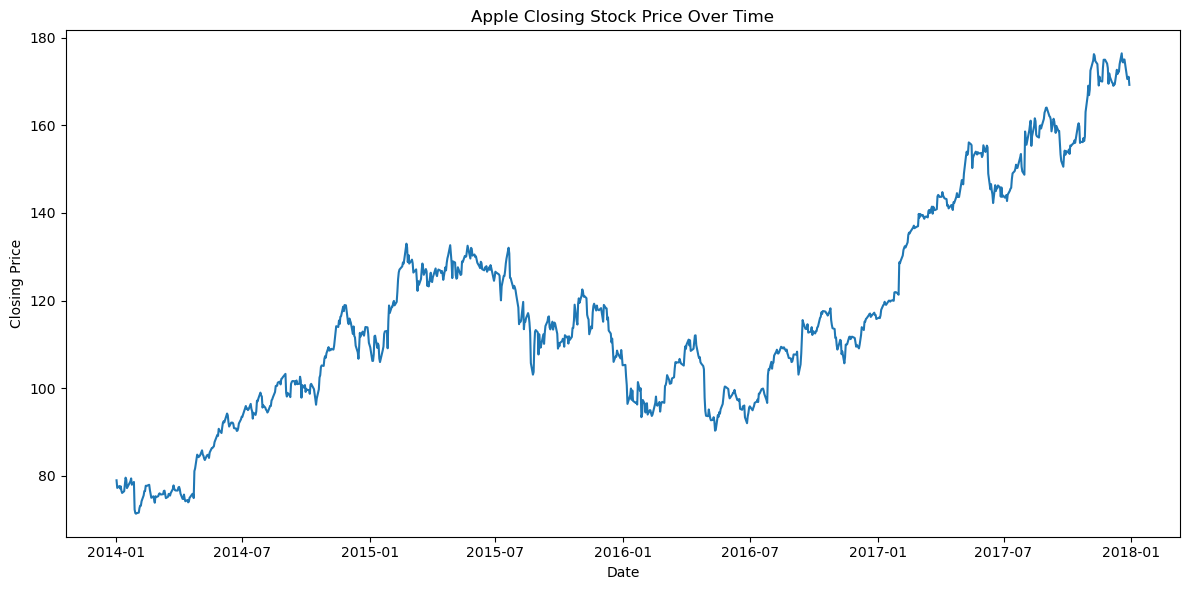

In [15]:
plt.figure(figsize=(12, 6))

plt.plot(apple.index, apple["close"])

plt.title("Apple Closing Stock Price Over Time")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.tight_layout()
plt.savefig(r"D:\projects\codveda project\level 2-task 2\plot\Apple Closing Stock Price Over Time", dpi=300, bbox_inches="tight")
plt.show()

In [16]:
#Overall, Apple stock shows a long-term upward trend, although several periods of decline and short-term volatility are visible.

In [17]:
apple["MA20"] = apple["close"].rolling(window=20).mean()
apple["MA50"] = apple["close"].rolling(window=50).mean()

In [18]:
apple[["close", "MA20", "MA50"]].head(55)

,close,MA20,MA50
date,,,
2014-01-02,79.0185,NaN,NaN
2014-01-03,77.2828,NaN,NaN
2014-01-06,77.7042,NaN,NaN
2014-01-07,77.1481,NaN,NaN
2014-01-08,77.6371,NaN,NaN
2014-01-09,76.6455,NaN,NaN
2014-01-10,76.1342,NaN,NaN
2014-01-13,76.5328,NaN,NaN
2014-01-14,78.0556,NaN,NaN


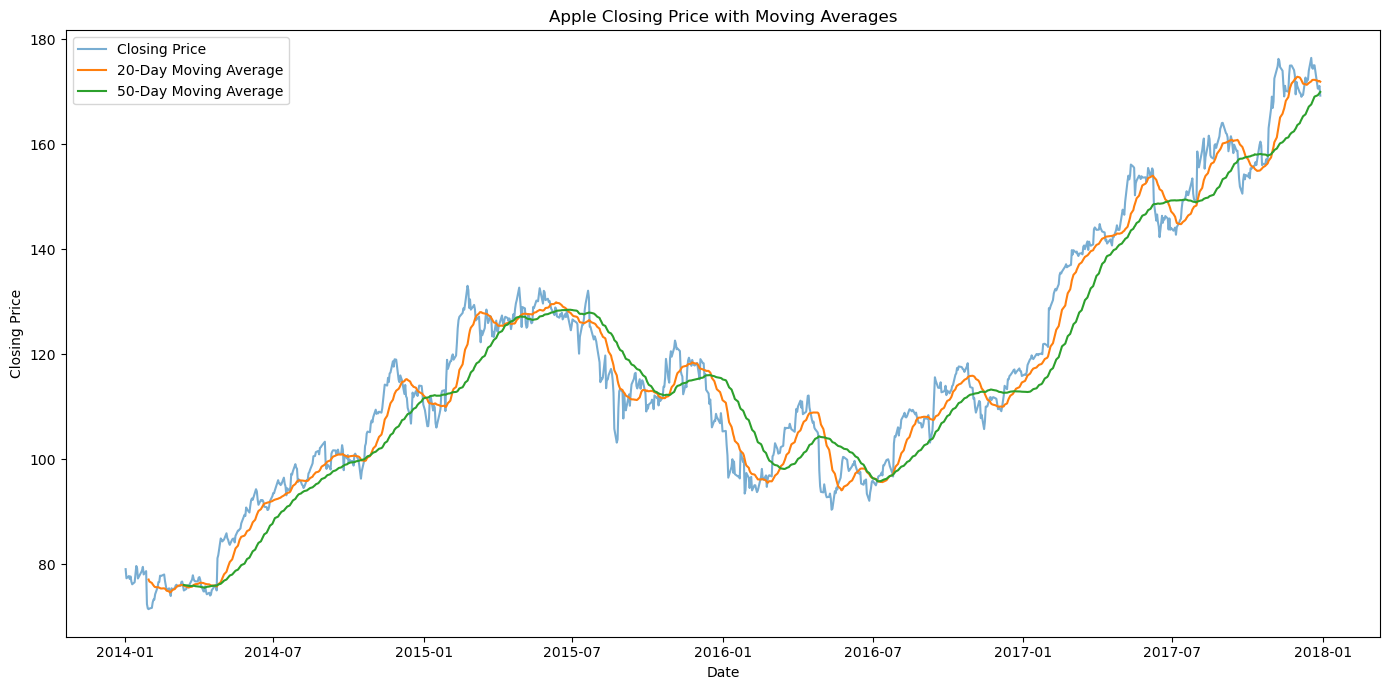

In [19]:
plt.figure(figsize=(14, 7))

plt.plot(
    apple.index,
    apple["close"],
    label="Closing Price",
    alpha=0.6
)

plt.plot(
    apple.index,
    apple["MA20"],
    label="20-Day Moving Average"
)

plt.plot(
    apple.index,
    apple["MA50"],
    label="50-Day Moving Average"
)

plt.title("Apple Closing Price with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend()
plt.tight_layout()
plt.savefig(r"D:\projects\codveda project\level 2-task 2\plot\Apple Closing Price with Moving Averages", dpi=300, bbox_inches="tight")
plt.show()

In [20]:
### Moving Average Analysis

#The 20-day moving average reacts more quickly to short-term changes in Apple's
#stock price, while the 50-day moving average provides a smoother representation
#of the longer-term trend.

#The moving averages make the declining period during 2015–2016 and the strong
#upward trend during 2017 easier to identify compared with the raw closing price.

In [21]:
monthly_close = apple["close"].resample("ME").last()
monthly_close.head()

date
2014-01-31    71.5142
2014-02-28    75.1771
2014-03-31    76.6771
2014-04-30    84.2985
2014-05-31    90.4285
Freq: ME, Name: close, dtype: float64

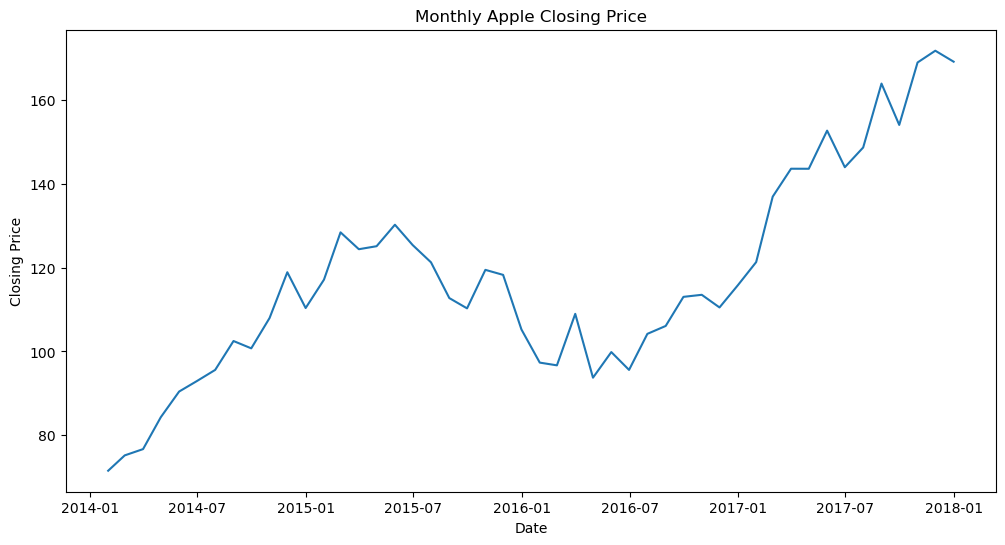

In [22]:
plt.figure(figsize=(12, 6))

plt.plot(monthly_close)

plt.title("Monthly Apple Closing Price")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.show()

In [23]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [24]:
decomposition = seasonal_decompose(
    monthly_close,
    model="additive",
    period=12
)

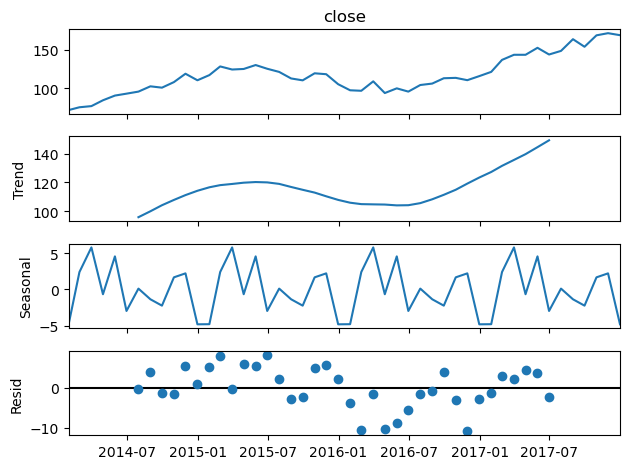

In [25]:
decomposition.plot()
plt.show()

In [26]:
### Time Series Decomposition

#The monthly Apple closing price was decomposed into trend, seasonal,
#and residual components using an additive model with a 12-month period.

#The trend component shows an upward movement until 2015, followed by
#a decline during 2015–2016 and a strong recovery and upward trend from
#late 2016 through 2017.

#The decomposition also identifies a repeating seasonal component.
#However, since the dataset covers only about four years, there are
#limited annual cycles available for analysis. Therefore, the seasonal
#pattern should not be interpreted as strong evidence of persistent
#annual seasonality.

#The residual component represents short-term variations that are not
#explained by the trend or seasonal components, with several larger
#deviations visible during the 2015–2016 period.

In [27]:
## Final Conclusion

#This project analyzed Apple (AAPL) stock prices as a time series using
#daily closing price data.

#The analysis showed that Apple's stock price followed an overall upward
#trend over the full period, although the trend was not continuous.
#A noticeable decline occurred during 2015–2016, followed by a strong
#recovery and upward movement throughout 2017.

#To reduce short-term fluctuations and make the underlying trend easier
#to observe, 20-day and 50-day moving averages were calculated.
#The 20-day moving average responded more quickly to short-term price
#changes, while the 50-day moving average provided a smoother view of
#the longer-term trend.

#The monthly closing price was also decomposed into trend, seasonal, and
#residual components using an additive time-series decomposition model.
#The trend component clearly reflected the main upward and downward
#movements observed in the original series.

#A repeating seasonal component was extracted by the model; however,
#because the dataset covers only about four years, the available number
#of annual cycles is limited. Therefore, the seasonal component should
#not be interpreted as strong evidence of persistent annual seasonality.

#The residual component captured short-term variations that were not
#explained by the trend or seasonal components.

#Overall, the time-series analysis successfully identified the main
#long-term movements, smoothed short-term fluctuations, and separated
#the observed stock price into interpretable components.